In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\sculptsoft\3 june\sample_-_superstore.csv")

In [ ]:
df.head()   

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [6]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [8]:
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Day'] = df['Order Date'].dt.day

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,3
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,5


In [10]:
df['Days_To_Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

In [12]:
df.head(15)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,3,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,4,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,4,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,4,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,5,7
5,6,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078,2023,1,6,4
6,7,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Art,Rogers Handheld Barrel Pencil Sharpener,5.480,2,0.0,1.4796,2023,1,6,4
7,8,US-2023-106054,2023-01-06,2023-01-07,First Class,JO-15145,Jack O'Briant,Corporate,United States,Athens,...,Art,"Dixon Prang Watercolor Pencils, 10-Color Set w...",12.780,3,0.0,5.2398,2023,1,6,1
8,9,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Binders,Ibico Hi-Tech Manual Binding System,609.980,2,0.0,274.4910,2023,1,6,4
9,10,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Fasteners,"Alliance Super-Size Bands, Assorted Sizes",31.120,4,0.0,0.3112,2023,1,6,4


In [15]:
df['Ship_Year'] = df['Ship Date'].dt.year
df['Ship_Month'] = df['Ship Date'].dt.month
df['Ship_Day'] = df['Ship Date'].dt.day

In [16]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,2,0.2,5.5512,2023,1,7,4,2023,1,7
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,2,0.8,-5.4870,2023,1,8,4,2023,1,8
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3,0.2,4.2717,2023,1,8,4,2023,1,8
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3,0.2,-64.7748,2023,1,8,4,2023,1,8
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,3,0.2,4.8840,2023,1,12,7,2023,1,12


In [17]:
df.drop(['Order Date', 'Ship Date'], axis=1, inplace=True)

In [18]:
df.head()

,Row ID,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,...,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day
0,1,US-2023-103800,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,...,2,0.2,5.5512,2023,1,7,4,2023,1,7
1,2,US-2023-112326,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,...,2,0.8,-5.4870,2023,1,8,4,2023,1,8
2,3,US-2023-112326,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,...,3,0.2,4.2717,2023,1,8,4,2023,1,8
3,4,US-2023-112326,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,...,3,0.2,-64.7748,2023,1,8,4,2023,1,8
4,5,US-2023-141817,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,...,3,0.2,4.8840,2023,1,12,7,2023,1,12


In [19]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417,2024.736414,7.732097,15.872572,3.961350,2024.736414,7.732097,15.872572
std,2942.898656,619.906839,2.228317,0.206249,232.465115,1.127971,3.356443,8.775481,1.742829,1.127971,3.356443,8.775481
min,1.000000,0.444000,1.000000,0.000000,-6599.978000,2023.000000,1.000000,1.000000,0.000000,2023.000000,1.000000,1.000000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800,2024.000000,5.000000,8.000000,3.000000,2024.000000,5.000000,8.000000
50%,5097.500000,53.910000,3.000000,0.200000,8.690000,2025.000000,9.000000,16.000000,4.000000,2025.000000,9.000000,16.000000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925,2026.000000,11.000000,24.000000,5.000000,2026.000000,11.000000,24.000000
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000,2027.000000,12.000000,31.000000,11.000000,2027.000000,12.000000,31.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Ship Mode       10194 non-null  object 
 3   Customer ID     10194 non-null  object 
 4   Customer Name   10194 non-null  object 
 5   Segment         10194 non-null  object 
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Region          10194 non-null  object 
 11  Product ID      10194 non-null  object 
 12  Category        10194 non-null  object 
 13  Sub-Category    10194 non-null  object 
 14  Product Name    10194 non-null  object 
 15  Sales           10194 non-null  float64
 16  Quantity        10194 non-null  int64  
 17  Discount        10194 non-null 

In [21]:
print(df["Ship Mode"].unique())

['Standard Class' 'First Class' 'Second Class' 'Same Day']


In [22]:
print(df["Customer Name"].unique())

['Darren Powers' 'Phillina Ober' 'Mick Brown' 'Maria Etezadi'
 "Jack O'Briant" 'Lycoris Saunders' 'Vivek Sundaresam' 'Melanie Seite'
 'Anthony Jacobs' 'Seth Vernon' 'Brian Dahlen' 'Natalie DeCherney'
 'Michael Moore' 'Chris Selesnick' 'Brendan Sweed' 'Erica Hackney'
 'Delfina Latchford' 'David Wiener' 'Toby Swindell' 'Hunter Lopez'
 'Xylona Preis' 'Mark Van Huff' 'Muhammed MacIntyre' 'Tom Boeckenhauer'
 'Jane Waco' 'Speros Goranitis' 'Ionia McGrath' 'Carol Adams'
 'Shirley Daniels' 'Ed Jacobs' 'Jasper Cacioppo' 'Mike Vittorini'
 'Liz Carlisle' 'Bradley Drucker' 'Eric Barreto' 'Cynthia Delaney'
 'Mark Haberlin' 'Deborah Brumfield' 'Neil Ducich' 'Cyma Kinney'
 'Nathan Mautz' 'Guy Armstrong' 'Natalie Fritzler' 'Sanjit Chand'
 'Marina Lichtenstein' 'Shui Tom' 'Barry Französisch' 'Michael Nguyen'
 'Troy Blackwell' 'Aaron Bergman' 'Linda Cazamias' 'Steven Roelle'
 'Tamara Manning' 'Sue Ann Reed' 'Michael Grace' 'Jennifer Halladay'
 'Joy Smith' 'Vicky Freymann' 'Shahid Collister' 'Dave Brooks

In [23]:
print(df["Segment"].unique())

['Consumer' 'Home Office' 'Corporate']


In [24]:
print(df["Country/Region"].unique())

['United States' 'Canada']


In [25]:
print(df["City"].unique())

['Houston' 'Naperville' 'Philadelphia' 'Henderson' 'Athens' 'Los Angeles'
 'Huntsville' 'Laredo' 'Springfield' 'Dover' 'San Francisco'
 'Mount Pleasant' 'Newark' 'Bossier City' 'Roswell' 'Scottsdale'
 'Jonesboro' 'Westland' 'Smyrna' 'Miami' 'Toronto' 'Lafayette' 'Las Vegas'
 'Rapid City' 'Alexandria' 'San Diego' 'New York City' 'Detroit'
 'Mission Viejo' 'Green Bay' 'Saint Petersburg' 'Seattle' 'Escondido'
 'Romeoville' 'Chesapeake' 'Linden' 'North Las Vegas' 'Columbia' 'Concord'
 'Dallas' 'Chicago' 'Lubbock' 'Arlington' 'Richmond' 'Woodstock'
 'Moreno Valley' 'El Paso' 'Medford' 'Columbus' 'Elmhurst' 'Wilmington'
 'Margate' 'Yonkers' 'Des Moines' 'Denver' 'Royal Oak' 'Roseville'
 'Calgary' 'Huntington Beach' 'Logan' 'Jacksonville' 'Tampa' 'Raleigh'
 'Lakeville' 'Jackson' 'Burbank' 'Lakeland' 'Knoxville' 'Hamilton'
 'Asheville' 'Tucson' 'Portage' 'Greensboro' 'Delray Beach' 'Fresno'
 'Pomona' 'Albuquerque' 'Plano' 'Brownsville' 'Long Beach' 'Apple Valley'
 'Vallejo' 'Revere' 'Virginia 

In [26]:
df.drop(['Customer Name'], axis=1, inplace=True)

In [27]:
df.head()

,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country/Region,City,State/Province,Postal Code,Region,...,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day
0,1,US-2023-103800,Standard Class,DP-13000,Consumer,United States,Houston,Texas,77095,Central,...,2,0.2,5.5512,2023,1,7,4,2023,1,7
1,2,US-2023-112326,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,...,2,0.8,-5.4870,2023,1,8,4,2023,1,8
2,3,US-2023-112326,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,...,3,0.2,4.2717,2023,1,8,4,2023,1,8
3,4,US-2023-112326,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,...,3,0.2,-64.7748,2023,1,8,4,2023,1,8
4,5,US-2023-141817,Standard Class,MB-18085,Consumer,United States,Philadelphia,Pennsylvania,19143,East,...,3,0.2,4.8840,2023,1,12,7,2023,1,12


In [28]:
# performing ordinal encoding on ship mode

ship_mode_map = {
    "Standard Class" : 1,
    "First Class" : 2,
    "Second Class" : 3,
    "Same Day" : 4
}

df["Ship Mode Map"] = df["Ship Mode"].map(ship_mode_map)

In [29]:
df.head(15)

,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country/Region,City,State/Province,Postal Code,Region,...,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map
0,1,US-2023-103800,Standard Class,DP-13000,Consumer,United States,Houston,Texas,77095,Central,...,0.2,5.5512,2023,1,7,4,2023,1,7,1
1,2,US-2023-112326,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,...,0.8,-5.4870,2023,1,8,4,2023,1,8,1
2,3,US-2023-112326,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,...,0.2,4.2717,2023,1,8,4,2023,1,8,1
3,4,US-2023-112326,Standard Class,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,...,0.2,-64.7748,2023,1,8,4,2023,1,8,1
4,5,US-2023-141817,Standard Class,MB-18085,Consumer,United States,Philadelphia,Pennsylvania,19143,East,...,0.2,4.8840,2023,1,12,7,2023,1,12,1
5,6,US-2023-167199,Standard Class,ME-17320,Home Office,United States,Henderson,Kentucky,42420,South,...,0.0,746.4078,2023,1,10,4,2023,1,10,1
6,7,US-2023-167199,Standard Class,ME-17320,Home Office,United States,Henderson,Kentucky,42420,South,...,0.0,1.4796,2023,1,10,4,2023,1,10,1
7,8,US-2023-106054,First Class,JO-15145,Corporate,United States,Athens,Georgia,30605,South,...,0.0,5.2398,2023,1,7,1,2023,1,7,2
8,9,US-2023-167199,Standard Class,ME-17320,Home Office,United States,Henderson,Kentucky,42420,South,...,0.0,274.4910,2023,1,10,4,2023,1,10,1
9,10,US-2023-167199,Standard Class,ME-17320,Home Office,United States,Henderson,Kentucky,42420,South,...,0.0,0.3112,2023,1,10,4,2023,1,10,1


In [30]:
df.drop(['Ship Mode'], axis=1, inplace=True)

In [31]:
df.head()

,Row ID,Order ID,Customer ID,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,...,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map
0,1,US-2023-103800,DP-13000,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,...,0.2,5.5512,2023,1,7,4,2023,1,7,1
1,2,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,...,0.8,-5.4870,2023,1,8,4,2023,1,8,1
2,3,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,...,0.2,4.2717,2023,1,8,4,2023,1,8,1
3,4,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,...,0.2,-64.7748,2023,1,8,4,2023,1,8,1
4,5,US-2023-141817,MB-18085,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,...,0.2,4.8840,2023,1,12,7,2023,1,12,1


In [32]:
df.shape

(10194, 25)

In [33]:
df.columns

Index(['Row ID', 'Order ID', 'Customer ID', 'Segment', 'Country/Region',
       'City', 'State/Province', 'Postal Code', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_Day',
       'Days_To_Ship', 'Ship_Year', 'Ship_Month', 'Ship_Day', 'Ship Mode Map'],
      dtype='object')

In [34]:
df.head()

,Row ID,Order ID,Customer ID,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,...,Discount,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map
0,1,US-2023-103800,DP-13000,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,...,0.2,5.5512,2023,1,7,4,2023,1,7,1
1,2,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,...,0.8,-5.4870,2023,1,8,4,2023,1,8,1
2,3,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,...,0.2,4.2717,2023,1,8,4,2023,1,8,1
3,4,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,...,0.2,-64.7748,2023,1,8,4,2023,1,8,1
4,5,US-2023-141817,MB-18085,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,...,0.2,4.8840,2023,1,12,7,2023,1,12,1


In [36]:
# Map of segment values
#['Consumer' 'Home Office' 'Corporate']

segment_map = {
    "Consumer" : 1,
    "Home Office" : 2,
    "Corporate" : 3
}

df["Segment_map"] = df["Segment"].map(segment_map)

In [37]:
df.head()

,Row ID,Order ID,Customer ID,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,...,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map
0,1,US-2023-103800,DP-13000,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,...,5.5512,2023,1,7,4,2023,1,7,1,1
1,2,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,...,-5.4870,2023,1,8,4,2023,1,8,1,2
2,3,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,...,4.2717,2023,1,8,4,2023,1,8,1,2
3,4,US-2023-112326,PO-19195,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,...,-64.7748,2023,1,8,4,2023,1,8,1,2
4,5,US-2023-141817,MB-18085,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,...,4.8840,2023,1,12,7,2023,1,12,1,1


In [38]:
df.drop(["Segment"], axis=1,inplace=True)

In [39]:
df.head()

,Row ID,Order ID,Customer ID,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,...,Profit,Order_Year,Order_Month,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map
0,1,US-2023-103800,DP-13000,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,...,5.5512,2023,1,7,4,2023,1,7,1,1
1,2,US-2023-112326,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,...,-5.4870,2023,1,8,4,2023,1,8,1,2
2,3,US-2023-112326,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,...,4.2717,2023,1,8,4,2023,1,8,1,2
3,4,US-2023-112326,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,...,-64.7748,2023,1,8,4,2023,1,8,1,2
4,5,US-2023-141817,MB-18085,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,...,4.8840,2023,1,12,7,2023,1,12,1,1


In [44]:
print(df["Country/Region"].value_counts())

Country/Region
United States    9994
Canada            200
Name: count, dtype: int64


In [ ]:
order_id_split = df["Order ID"].str.split('-', expand=True)

In [ ]:
df["ID_Country_Code"] = order_id_split[0]
df["ID_Year"] = order_id_split[1]
df["ID_numer"] = order_id_split[2]

In [52]:
df.head()

,Row ID,Customer ID,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,ID_Country_Code,ID_Year,ID_numer,ID_number
0,1,DP-13000,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,...,4,2023,1,7,1,1,US,2023,103800,103800
1,2,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,...,4,2023,1,8,1,2,US,2023,112326,112326
2,3,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,...,4,2023,1,8,1,2,US,2023,112326,112326
3,4,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,...,4,2023,1,8,1,2,US,2023,112326,112326
4,5,MB-18085,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,...,7,2023,1,12,1,1,US,2023,141817,141817


In [ ]:
df.drop(["Order ID"],axis=1, inplace = True)

In [50]:
df.head()

,Row ID,Customer ID,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,...,Order_Day,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,ID_Country_Code,ID_Year,ID_numer
0,1,DP-13000,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,...,7,4,2023,1,7,1,1,US,2023,103800
1,2,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,...,8,4,2023,1,8,1,2,US,2023,112326
2,3,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,...,8,4,2023,1,8,1,2,US,2023,112326
3,4,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,...,8,4,2023,1,8,1,2,US,2023,112326
4,5,MB-18085,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,...,12,7,2023,1,12,1,1,US,2023,141817


In [54]:
df.columns

Index(['Row ID', 'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year',
       'Order_Month', 'Order_Day', 'Days_To_Ship', 'Ship_Year', 'Ship_Month',
       'Ship_Day', 'Ship Mode Map', 'Segment_map', 'ID_Country_Code',
       'ID_Year', 'ID_numer', 'ID_number'],
      dtype='object')

In [55]:
df.drop(["ID_number"], axis=1,inplace = True)

In [56]:
df.columns

Index(['Row ID', 'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year',
       'Order_Month', 'Order_Day', 'Days_To_Ship', 'Ship_Year', 'Ship_Month',
       'Ship_Day', 'Ship Mode Map', 'Segment_map', 'ID_Country_Code',
       'ID_Year', 'ID_numer'],
      dtype='object')

In [57]:
df.rename(columns={
    "ID_Country_Code" : "Order_ID_Country_Code",
    "ID_Year" : "Order_ID_Year",
    "ID_numer" : "Order_ID_number"
},inplace= True)

In [58]:
df.columns

Index(['Row ID', 'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year',
       'Order_Month', 'Order_Day', 'Days_To_Ship', 'Ship_Year', 'Ship_Month',
       'Ship_Day', 'Ship Mode Map', 'Segment_map', 'Order_ID_Country_Code',
       'Order_ID_Year', 'Order_ID_number'],
      dtype='object')

In [59]:
# country map

country_map = {
    "United States" : 1,
    "Canada" : 2
}

df["Country Map"] = df["Country/Region"].map(country_map)

In [60]:
df.head()

,Row ID,Customer ID,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,1,DP-13000,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,...,4,2023,1,7,1,1,US,2023,103800,1
1,2,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,...,4,2023,1,8,1,2,US,2023,112326,1
2,3,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,...,4,2023,1,8,1,2,US,2023,112326,1
3,4,PO-19195,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,...,4,2023,1,8,1,2,US,2023,112326,1
4,5,MB-18085,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,...,7,2023,1,12,1,1,US,2023,141817,1


In [61]:
df.drop(["Country/Region"],axis=1, inplace = True)

In [62]:
df.head()

,Row ID,Customer ID,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,1,DP-13000,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",...,4,2023,1,7,1,1,US,2023,103800,1
1,2,PO-19195,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,...,4,2023,1,8,1,2,US,2023,112326,1
2,3,PO-19195,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,...,4,2023,1,8,1,2,US,2023,112326,1
3,4,PO-19195,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,...,4,2023,1,8,1,2,US,2023,112326,1
4,5,MB-18085,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,...,7,2023,1,12,1,1,US,2023,141817,1


In [63]:
df.columns


Index(['Row ID', 'Customer ID', 'City', 'State/Province', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month',
       'Order_Day', 'Days_To_Ship', 'Ship_Year', 'Ship_Month', 'Ship_Day',
       'Ship Mode Map', 'Segment_map', 'Order_ID_Country_Code',
       'Order_ID_Year', 'Order_ID_number', 'Country Map'],
      dtype='object')

In [126]:
# print(df["City"].nunique())
# print(df["Product Name"].nunique())
# print(df["State/Province"].nunique())
print(df["Region"].unique())
# print(df["Category"].unique())
# print(df["Sub-Category"].unique())
# print(df["Customer ID"].unique())
# print(df["Product ID"].nunique())
# print(df["Postal Code"].nunique())


[0 1 2 3]


In [72]:
df.drop(["Row ID"], axis= 1, inplace = True)

In [74]:
df.drop(["Customer ID"], axis= 1, inplace = True)

In [75]:
df.head()

,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,...,4,2023,1,7,1,1,US,2023,103800,1
1,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,...,4,2023,1,8,1,2,US,2023,112326,1
2,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,...,4,2023,1,8,1,2,US,2023,112326,1
3,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,...,4,2023,1,8,1,2,US,2023,112326,1
4,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,...,7,2023,1,12,1,1,US,2023,141817,1


In [78]:
df.drop(["Product ID"],axis=1,inplace = True)

In [79]:
df.head()

,City,State/Province,Postal Code,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,Houston,Texas,77095,Central,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,...,4,2023,1,7,1,1,US,2023,103800,1
1,Naperville,Illinois,60540,Central,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,...,4,2023,1,8,1,2,US,2023,112326,1
2,Naperville,Illinois,60540,Central,Office Supplies,Labels,Avery 508,11.784,3,0.2,...,4,2023,1,8,1,2,US,2023,112326,1
3,Naperville,Illinois,60540,Central,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,...,4,2023,1,8,1,2,US,2023,112326,1
4,Philadelphia,Pennsylvania,19143,East,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,...,7,2023,1,12,1,1,US,2023,141817,1


In [81]:
df.drop(["Product Name"], axis= 1, inplace= True)

In [82]:
df.head()

,City,State/Province,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,Houston,Texas,77095,Central,Office Supplies,Paper,16.448,2,0.2,5.5512,...,4,2023,1,7,1,1,US,2023,103800,1
1,Naperville,Illinois,60540,Central,Office Supplies,Binders,3.540,2,0.8,-5.4870,...,4,2023,1,8,1,2,US,2023,112326,1
2,Naperville,Illinois,60540,Central,Office Supplies,Labels,11.784,3,0.2,4.2717,...,4,2023,1,8,1,2,US,2023,112326,1
3,Naperville,Illinois,60540,Central,Office Supplies,Storage,272.736,3,0.2,-64.7748,...,4,2023,1,8,1,2,US,2023,112326,1
4,Philadelphia,Pennsylvania,19143,East,Office Supplies,Art,19.536,3,0.2,4.8840,...,7,2023,1,12,1,1,US,2023,141817,1


In [89]:
df.drop(columns=['City'], inplace=True)

In [92]:
le = LabelEncoder()
df['State/Province'] = le.fit_transform(df['State/Province'])

In [93]:
df.head()

,State/Province,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,51,77095,Central,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,...,4,2023,1,7,1,1,US,2023,103800,1
1,13,60540,Central,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,...,4,2023,1,8,1,2,US,2023,112326,1
2,13,60540,Central,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,...,4,2023,1,8,1,2,US,2023,112326,1
3,13,60540,Central,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,...,4,2023,1,8,1,2,US,2023,112326,1
4,43,19143,East,Office Supplies,Art,19.536,3,0.2,4.8840,2023,...,7,2023,1,12,1,1,US,2023,141817,1


In [94]:
df.drop(["Postal Code"], axis=1, inplace = True)

In [96]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,51,Central,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,1,...,4,2023,1,7,1,1,US,2023,103800,1
1,13,Central,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
2,13,Central,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
3,13,Central,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
4,43,East,Office Supplies,Art,19.536,3,0.2,4.8840,2023,1,...,7,2023,1,12,1,1,US,2023,141817,1


In [100]:
df["Region"] = le.fit_transform(df["Region"])

In [101]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,51,0,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,1,...,4,2023,1,7,1,1,US,2023,103800,1
1,13,0,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
2,13,0,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
3,13,0,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
4,43,1,Office Supplies,Art,19.536,3,0.2,4.8840,2023,1,...,7,2023,1,12,1,1,US,2023,141817,1


In [102]:
df.columns

Index(['State/Province', 'Region', 'Category', 'Sub-Category', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month',
       'Order_Day', 'Days_To_Ship', 'Ship_Year', 'Ship_Month', 'Ship_Day',
       'Ship Mode Map', 'Segment_map', 'Order_ID_Country_Code',
       'Order_ID_Year', 'Order_ID_number', 'Country Map'],
      dtype='object')

In [103]:
category_means = df.groupby("Category")["Profit"].mean()
subcategory_means = df.groupby("Sub-Category")["Profit"].mean()

In [104]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,51,0,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,1,...,4,2023,1,7,1,1,US,2023,103800,1
1,13,0,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
2,13,0,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
3,13,0,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
4,43,1,Office Supplies,Art,19.536,3,0.2,4.8840,2023,1,...,7,2023,1,12,1,1,US,2023,141817,1


In [105]:
df["Category_Encoded"] = df["Category"].map(category_means)
df["SubCategory_Encoded"] = df["Sub-Category"].map(subcategory_means)

In [106]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map,Category_Encoded,SubCategory_Encoded
0,51,0,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,1,...,1,7,1,1,US,2023,103800,1,20.565183,24.936060
1,13,0,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,1,...,1,8,1,2,US,2023,112326,1,20.565183,20.301098
2,13,0,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,1,...,1,8,1,2,US,2023,112326,1,20.565183,15.143418
3,13,0,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,1,...,1,8,1,2,US,2023,112326,1,20.565183,24.865784
4,43,1,Office Supplies,Art,19.536,3,0.2,4.8840,2023,1,...,1,12,1,1,US,2023,141817,1,20.565183,8.103771


In [107]:
df.columns

Index(['State/Province', 'Region', 'Category', 'Sub-Category', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month',
       'Order_Day', 'Days_To_Ship', 'Ship_Year', 'Ship_Month', 'Ship_Day',
       'Ship Mode Map', 'Segment_map', 'Order_ID_Country_Code',
       'Order_ID_Year', 'Order_ID_number', 'Country Map', 'Category_Encoded',
       'SubCategory_Encoded'],
      dtype='object')

In [108]:
df.drop(["SubCategory_Encoded","Category_Encoded"],axis = 1, inplace = True)

In [109]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,51,0,Office Supplies,Paper,16.448,2,0.2,5.5512,2023,1,...,4,2023,1,7,1,1,US,2023,103800,1
1,13,0,Office Supplies,Binders,3.540,2,0.8,-5.4870,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
2,13,0,Office Supplies,Labels,11.784,3,0.2,4.2717,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
3,13,0,Office Supplies,Storage,272.736,3,0.2,-64.7748,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
4,43,1,Office Supplies,Art,19.536,3,0.2,4.8840,2023,1,...,7,2023,1,12,1,1,US,2023,141817,1


In [ ]:
# Map Sub-Category 
df["Sub-Category"] = le.fit_transform(df["Sub-Category"])

In [112]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Days_To_Ship,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map
0,51,0,Office Supplies,12,16.448,2,0.2,5.5512,2023,1,...,4,2023,1,7,1,1,US,2023,103800,1
1,13,0,Office Supplies,3,3.540,2,0.8,-5.4870,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
2,13,0,Office Supplies,10,11.784,3,0.2,4.2717,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
3,13,0,Office Supplies,14,272.736,3,0.2,-64.7748,2023,1,...,4,2023,1,8,1,2,US,2023,112326,1
4,43,1,Office Supplies,2,19.536,3,0.2,4.8840,2023,1,...,7,2023,1,12,1,1,US,2023,141817,1


In [114]:
#['Office Supplies' 'Furniture' 'Technology']
# Map category

category_map = {
    "Office Supplies" : 1,
    "Furniture" : 2,
    "Technology" : 3
}

df["Category map"] = df["Category"].map(category_map)

In [115]:
df.head()

,State/Province,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,...,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map,Category map
0,51,0,Office Supplies,12,16.448,2,0.2,5.5512,2023,1,...,2023,1,7,1,1,US,2023,103800,1,1
1,13,0,Office Supplies,3,3.540,2,0.8,-5.4870,2023,1,...,2023,1,8,1,2,US,2023,112326,1,1
2,13,0,Office Supplies,10,11.784,3,0.2,4.2717,2023,1,...,2023,1,8,1,2,US,2023,112326,1,1
3,13,0,Office Supplies,14,272.736,3,0.2,-64.7748,2023,1,...,2023,1,8,1,2,US,2023,112326,1,1
4,43,1,Office Supplies,2,19.536,3,0.2,4.8840,2023,1,...,2023,1,12,1,1,US,2023,141817,1,1


In [116]:
df.drop(["Category"], axis = 1, inplace= True)

In [117]:
df.head()

,State/Province,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,...,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map,Category map
0,51,0,12,16.448,2,0.2,5.5512,2023,1,7,...,2023,1,7,1,1,US,2023,103800,1,1
1,13,0,3,3.540,2,0.8,-5.4870,2023,1,8,...,2023,1,8,1,2,US,2023,112326,1,1
2,13,0,10,11.784,3,0.2,4.2717,2023,1,8,...,2023,1,8,1,2,US,2023,112326,1,1
3,13,0,14,272.736,3,0.2,-64.7748,2023,1,8,...,2023,1,8,1,2,US,2023,112326,1,1
4,43,1,2,19.536,3,0.2,4.8840,2023,1,12,...,2023,1,12,1,1,US,2023,141817,1,1


In [119]:
df.columns

Index(['State/Province', 'Region', 'Sub-Category', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_Day',
       'Days_To_Ship', 'Ship_Year', 'Ship_Month', 'Ship_Day', 'Ship Mode Map',
       'Segment_map', 'Order_ID_Country_Code', 'Order_ID_Year',
       'Order_ID_number', 'Country Map', 'Category map'],
      dtype='object')

In [ ]:
order_id_country_map = {
    "US" : 0,
    "CA" : 1
}

df["Order_ID_Country_Code"] = df["Order_ID_Country_Code"].map(order_id_country_map) 

In [ ]:
print((df["Order_ID_Country_map"] == df["Region"]).all())

False


In [155]:
print(df["Country Map"].sum())

10394


In [156]:
print(df["Order_ID_Country_map"].sum())

200


In [157]:
print(df["Country Map"].unique())

[1 2]


In [158]:
df.head(15)

,State/Province,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,...,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map,Category map,Order_ID_Country_map
0,51,0,12,16.448,2,0.2,5.5512,2023,1,7,...,1,7,1,1,US,2023,103800,1,1,0
1,13,0,3,3.540,2,0.8,-5.4870,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
2,13,0,10,11.784,3,0.2,4.2717,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
3,13,0,14,272.736,3,0.2,-64.7748,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
4,43,1,2,19.536,3,0.2,4.8840,2023,1,12,...,1,12,1,1,US,2023,141817,1,1,0
5,17,2,5,2573.820,9,0.0,746.4078,2023,1,10,...,1,10,1,2,US,2023,167199,1,2,0
6,17,2,2,5.480,2,0.0,1.4796,2023,1,10,...,1,10,1,2,US,2023,167199,1,1,0
7,11,2,2,12.780,3,0.0,5.2398,2023,1,7,...,1,7,2,3,US,2023,106054,1,1,0
8,17,2,3,609.980,2,0.0,274.4910,2023,1,10,...,1,10,1,2,US,2023,167199,1,1,0
9,17,2,8,31.120,4,0.0,0.3112,2023,1,10,...,1,10,1,2,US,2023,167199,1,1,0


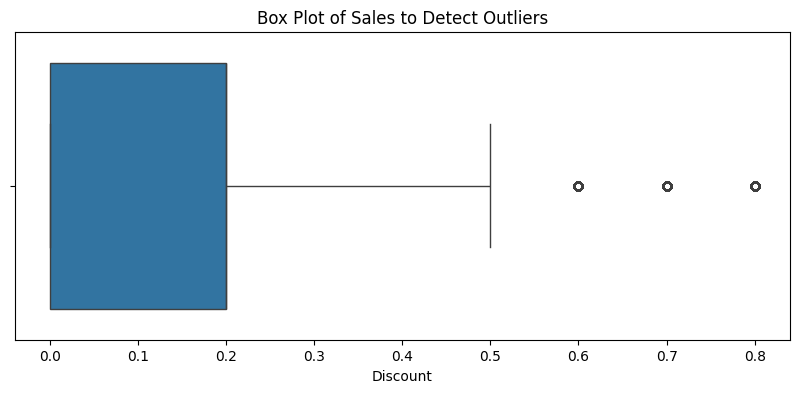

In [163]:
#To find outliers in the sales columns

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Discount'])
plt.title('Box Plot of Sales to Detect Outliers')
plt.show()

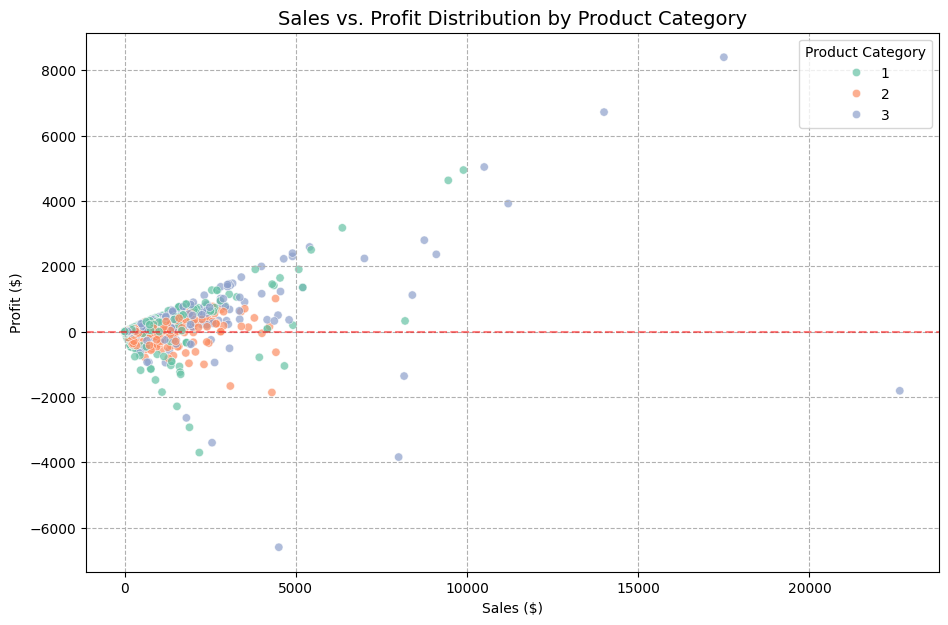

In [151]:
plt.figure(figsize=(11, 7))

# Color-code the points by Product Category
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category map', alpha=0.7, palette='Set2')

# Draw a dashed baseline at Profit = 0 to clearly separate profit from loss
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.title('Sales vs. Profit Distribution by Product Category', fontsize=14)
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.legend(title='Product Category')
plt.grid(True, linestyle='--', alpha=1)
plt.show()

In [152]:
df.head()

,State/Province,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,...,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map,Category map,Order_ID_Country_map
0,51,0,12,16.448,2,0.2,5.5512,2023,1,7,...,1,7,1,1,US,2023,103800,1,1,0
1,13,0,3,3.540,2,0.8,-5.4870,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
2,13,0,10,11.784,3,0.2,4.2717,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
3,13,0,14,272.736,3,0.2,-64.7748,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
4,43,1,2,19.536,3,0.2,4.8840,2023,1,12,...,1,12,1,1,US,2023,141817,1,1,0


In [159]:
df.head()

,State/Province,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,...,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Country_Code,Order_ID_Year,Order_ID_number,Country Map,Category map,Order_ID_Country_map
0,51,0,12,16.448,2,0.2,5.5512,2023,1,7,...,1,7,1,1,US,2023,103800,1,1,0
1,13,0,3,3.540,2,0.8,-5.4870,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
2,13,0,10,11.784,3,0.2,4.2717,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
3,13,0,14,272.736,3,0.2,-64.7748,2023,1,8,...,1,8,1,2,US,2023,112326,1,1,0
4,43,1,2,19.536,3,0.2,4.8840,2023,1,12,...,1,12,1,1,US,2023,141817,1,1,0


In [160]:
df.drop(["Order_ID_Country_Code"],axis = 1, inplace= True)

In [162]:
df.head(15)

,State/Province,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,...,Ship_Year,Ship_Month,Ship_Day,Ship Mode Map,Segment_map,Order_ID_Year,Order_ID_number,Country Map,Category map,Order_ID_Country_map
0,51,0,12,16.448,2,0.2,5.5512,2023,1,7,...,2023,1,7,1,1,2023,103800,1,1,0
1,13,0,3,3.540,2,0.8,-5.4870,2023,1,8,...,2023,1,8,1,2,2023,112326,1,1,0
2,13,0,10,11.784,3,0.2,4.2717,2023,1,8,...,2023,1,8,1,2,2023,112326,1,1,0
3,13,0,14,272.736,3,0.2,-64.7748,2023,1,8,...,2023,1,8,1,2,2023,112326,1,1,0
4,43,1,2,19.536,3,0.2,4.8840,2023,1,12,...,2023,1,12,1,1,2023,141817,1,1,0
5,17,2,5,2573.820,9,0.0,746.4078,2023,1,10,...,2023,1,10,1,2,2023,167199,1,2,0
6,17,2,2,5.480,2,0.0,1.4796,2023,1,10,...,2023,1,10,1,2,2023,167199,1,1,0
7,11,2,2,12.780,3,0.0,5.2398,2023,1,7,...,2023,1,7,2,3,2023,106054,1,1,0
8,17,2,3,609.980,2,0.0,274.4910,2023,1,10,...,2023,1,10,1,2,2023,167199,1,1,0
9,17,2,8,31.120,4,0.0,0.3112,2023,1,10,...,2023,1,10,1,2,2023,167199,1,1,0


In [164]:
df.columns

Index(['State/Province', 'Region', 'Sub-Category', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_Day',
       'Days_To_Ship', 'Ship_Year', 'Ship_Month', 'Ship_Day', 'Ship Mode Map',
       'Segment_map', 'Order_ID_Year', 'Order_ID_number', 'Country Map',
       'Category map', 'Order_ID_Country_map'],
      dtype='object')

In [165]:
df.drop(["Order_Day","Ship_Month", "Ship_Day", "Ship_Year"], axis =1, inplace=True)

In [166]:
df.head()

,State/Province,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Days_To_Ship,Ship Mode Map,Segment_map,Order_ID_Year,Order_ID_number,Country Map,Category map,Order_ID_Country_map
0,51,0,12,16.448,2,0.2,5.5512,2023,1,4,1,1,2023,103800,1,1,0
1,13,0,3,3.540,2,0.8,-5.4870,2023,1,4,1,2,2023,112326,1,1,0
2,13,0,10,11.784,3,0.2,4.2717,2023,1,4,1,2,2023,112326,1,1,0
3,13,0,14,272.736,3,0.2,-64.7748,2023,1,4,1,2,2023,112326,1,1,0
4,43,1,2,19.536,3,0.2,4.8840,2023,1,7,1,1,2023,141817,1,1,0


In [167]:
df.columns

Index(['State/Province', 'Region', 'Sub-Category', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Days_To_Ship',
       'Ship Mode Map', 'Segment_map', 'Order_ID_Year', 'Order_ID_number',
       'Country Map', 'Category map', 'Order_ID_Country_map'],
      dtype='object')